![pageindex_banner](https://pageindex.ai/static/images/pageindex_banner.jpg)


<div align="center">
<p><i>Reasoning-based RAG&nbsp; ◦ &nbsp;No Vector DB&nbsp; ◦ &nbsp;No Chunking&nbsp; ◦ &nbsp;Human-like Retrieval</i></p>
</div>

<div align="center">
<p>
  <a href="https://vectify.ai">🏠 Homepage</a>&nbsp; • &nbsp;
  <a href="https://chat.pageindex.ai">💻 Chat</a>&nbsp; • &nbsp;
  <a href="https://pageindex.ai/mcp">🔌 MCP</a>&nbsp; • &nbsp;
  <a href="https://docs.pageindex.ai/quickstart">📚 API</a>&nbsp; • &nbsp;
  <a href="https://github.com/VectifyAI/PageIndex">📦 GitHub</a>&nbsp; • &nbsp;
  <a href="https://discord.com/invite/VuXuf29EUj">💬 Discord</a>&nbsp; • &nbsp;
  <a href="https://ii2abc2jejf.typeform.com/to/tK3AXl8T">✉️ Contact</a>&nbsp;
</p>
</div>

<div align="center">

[![Star us on GitHub](https://img.shields.io/github/stars/VectifyAI/PageIndex?style=for-the-badge&logo=github&label=⭐️%20Star%20Us)](https://github.com/VectifyAI/PageIndex) &nbsp;&nbsp; [![Follow us on X](https://img.shields.io/badge/Follow%20Us-000000?style=for-the-badge&logo=x&logoColor=white)](https://twitter.com/VectifyAI)

</div>

---

> Check out our blog post, "[Do We Still Need OCR?](https://pageindex.ai/blog/do-we-need-ocr)", for a more detailed discussion.

# A Vision-based, Vectorless RAG System for Long Documents


In modern document question answering (QA) systems, Optical Character Recognition (OCR) serves an important role by converting PDF pages into text that can be processed by Large Language Models (LLMs). The resulting text can provide contextual input that enables LLMs to perform question answering over document content.

Traditional OCR systems typically use a two-stage process that first detects the layout of a PDF — dividing it into text, tables, and images — and then recognizes and converts these elements into plain text. With the rise of vision-language models (VLMs) (such as [Qwen-VL](https://github.com/QwenLM/Qwen3-VL) and [GPT-4.1](https://openai.com/index/gpt-4-1/)), new end-to-end OCR models like [DeepSeek-OCR](https://github.com/deepseek-ai/DeepSeek-OCR) have emerged. These models jointly understand visual and textual information, enabling direct interpretation of PDFs without an explicit layout detection step.

However, this paradigm shift raises an important question: 


> **If a VLM can already process both the document images and the query to produce an answer directly, do we still need the intermediate OCR step?**

In this notebook, we give a practical implementation of a vision-based question-answering system for long documents, without relying on OCR. Specifically, we use PageIndex as a reasoning-based retrieval layer and OpenAI's multimodal GPT-4.1 as the VLM for visual reasoning and answer generation.

See the original [blog post](https://pageindex.ai/blog/do-we-need-ocr) for a more detailed discussion on how VLMs can replace traditional OCR pipelines in document question-answering.

## 📝 Notebook Overview

This notebook demonstrates a *minimal*, **vision-based vectorless RAG** pipeline for long documents with PageIndex, using only visual context from PDF pages. You will learn how to:
- [x] Build a PageIndex tree structure of a document
- [x] Perform reasoning-based retrieval with tree search
- [x] Extract PDF page images of retrieved tree nodes for visual context
- [x] Generate answers using VLM with PDF image inputs only (no OCR required)

> ⚡ Note: This example uses PageIndex's reasoning-based retrieval with OpenAI's multimodal GPT-4.1 model for both tree search and visual context reasoning.

---

## Step 0: Preparation

This notebook demonstrates **Vision-based RAG** with PageIndex, using PDF page images as visual context for retrieval and answer generation.



#### 0.1 Install PageIndex

In [1]:
%pip install -q --upgrade pageindex requests ollama PyMuPDF


Note: you may need to restart the kernel to use updated packages.


#### 0.2 Setup PageIndex

In [2]:
from pageindex import PageIndexClient
import pageindex.utils as utils

# Get your PageIndex API key from https://dash.pageindex.ai/api-keys
PAGEINDEX_API_KEY = "f1556e8c08ce4e26bd5fa373e9fcf097"
pi_client = PageIndexClient(api_key=PAGEINDEX_API_KEY)

#### 0.3 Setup Local VLM

Choose your preferred local multimodal model through Ollama. In this notebook, `qwen2.5vl:3b` is used as the single VLM for both text-only tree search and vision-based answering.


In [3]:
import fitz, base64, os
import ollama

# Local Ollama multimodal model installed on your machine.
VISION_MODEL = "qwen2.5vl:3b"
OLLAMA_HOST = "http://localhost:11434"
OLLAMA_NUM_CTX = 8192

async def call_vlm(prompt, image_paths=None, model=VISION_MODEL):
    client = ollama.AsyncClient(host=OLLAMA_HOST)

    message = {"role": "user", "content": prompt} # Use LLM only

    if image_paths: # If image available, feed image
        images = []
        for image in image_paths:
            if os.path.exists(image):
                with open(image, "rb") as image_file:
                    image_data = base64.b64encode(image_file.read()).decode("utf-8")
                    images.append(image_data)

        if images:
            message["images"] = images

    response = await client.chat(
        model=model,
        messages=[message],
        options={"temperature": 0, "num_ctx": OLLAMA_NUM_CTX},
    )
    return response["message"]["content"].strip()


#### 0.4 PDF Image Extraction Helper Functions


In [4]:
def extract_pdf_page_images(pdf_path, output_dir="pdf_images"):     # Convert PDF to images
    os.makedirs(output_dir, exist_ok=True)
    pdf_document = fitz.open(pdf_path)
    page_images = {}
    total_pages = len(pdf_document)
    for page_number in range(len(pdf_document)):
        page = pdf_document.load_page(page_number)
        # Convert page to image
        mat = fitz.Matrix(2.0, 2.0)  # 2x zoom for better quality
        pix = page.get_pixmap(matrix=mat)
        img_data = pix.tobytes("jpeg")
        image_path = os.path.join(output_dir, f"page_{page_number + 1}.jpg")
        with open(image_path, "wb") as image_file:
            image_file.write(img_data)
        page_images[page_number + 1] = image_path
        print(f"Saved page {page_number + 1} image: {image_path}")
    pdf_document.close()
    return page_images, total_pages

def get_page_images_for_nodes(node_list, node_map, page_images):        
    # Get PDF page images for retrieved nodes
    image_paths = []
    seen_pages = set()
    for node_id in node_list:
        node_info = node_map[node_id]
        for page_num in range(node_info['start_index'], node_info['end_index'] + 1):
            if page_num not in seen_pages:
                image_paths.append(page_images[page_num])
                seen_pages.add(page_num)
    return image_paths


## Step 1: PageIndex Tree Generation

#### 1.1 Submit a document for generating PageIndex tree

In [5]:
import os, requests

# You can also use our GitHub repo to generate PageIndex tree
# https://github.com/VectifyAI/PageIndex

pdf_url = "https://arxiv.org/pdf/1706.03762.pdf"  # the "Attention Is All You Need" paper
pdf_path = os.path.join("../data", pdf_url.split('/')[-1])
os.makedirs(os.path.dirname(pdf_path), exist_ok=True)

response = requests.get(pdf_url)
with open(pdf_path, "wb") as f:
    f.write(response.content)
print(f"Downloaded {pdf_url}\n")

# Extract page images from PDF
print("Extracting page images...")
page_images, total_pages = extract_pdf_page_images(pdf_path)
print(f"Extracted {len(page_images)} page images from {total_pages} total pages.\n")

doc_id = pi_client.submit_document(pdf_path)["doc_id"]
print('Document Submitted:', doc_id)

Downloaded https://arxiv.org/pdf/1706.03762.pdf

Extracting page images...
Saved page 1 image: pdf_images/page_1.jpg
Saved page 2 image: pdf_images/page_2.jpg
Saved page 3 image: pdf_images/page_3.jpg
Saved page 4 image: pdf_images/page_4.jpg
Saved page 5 image: pdf_images/page_5.jpg
Saved page 6 image: pdf_images/page_6.jpg
Saved page 7 image: pdf_images/page_7.jpg
Saved page 8 image: pdf_images/page_8.jpg
Saved page 9 image: pdf_images/page_9.jpg
Saved page 10 image: pdf_images/page_10.jpg
Saved page 11 image: pdf_images/page_11.jpg
Saved page 12 image: pdf_images/page_12.jpg
Saved page 13 image: pdf_images/page_13.jpg
Saved page 14 image: pdf_images/page_14.jpg
Saved page 15 image: pdf_images/page_15.jpg
Extracted 15 page images from 15 total pages.

Document Submitted: pi-cmr4nls2y002j01pjepkfo973


#### 1.2 Get the generated PageIndex tree structure

In [13]:
if pi_client.is_retrieval_ready(doc_id):
    tree = pi_client.get_tree(doc_id, node_summary=True)['result']
    print('Simplified Tree Structure of the Document:')
    utils.print_tree(tree, exclude_fields=['text'])
else:
    print("Processing document, please try again later...")

Simplified Tree Structure of the Document:
[{'title': 'Attention Is All You Need',
  'node_id': '0000',
  'page_index': 1,
  'prefix_summary': '# Attention Is All You Need\n\n**Ashish Va...',
  'nodes': [{'title': 'Abstract',
             'node_id': '0001',
             'page_index': 1,
             'summary': 'The text introduces the Transformer, a n...'},
            {'title': '1 Introduction',
             'node_id': '0002',
             'page_index': 2,
             'summary': 'This text introduces the Transformer, a ...'},
            {'title': '2 Background',
             'node_id': '0003',
             'page_index': 2,
             'summary': 'This section reviews existing architectu...'},
            {'title': '3 Model Architecture',
             'node_id': '0004',
             'page_index': 2,
             'prefix_summary': 'The text describes the standard encoder-...',
             'nodes': [{'title': '3.1 Encoder and Decoder Stacks',
                        'node_id': '0005'

In [14]:
tree

[{'title': 'Attention Is All You Need',
  'node_id': '0000',
  'page_index': 1,
  'prefix_summary': '# Attention Is All You Need\n\n**Ashish Vaswani***\nGoogle Brain\navaswani@google.com\n\n**Noam Shazeer***\nGoogle Brain\nnoam@google.com\n\n**Niki Parmar***\nGoogle Research\nnikip@google.com\n\n**Jakob Uszkoreit***\nGoogle Research\nusz@google.com\n\n**Llion Jones***\nGoogle Research\nllion@google.com\n\n**Aidan N. Gomez*** †\nUniversity of Toronto\naidan@cs.toronto.edu\n\n**Łukasz Kaiser***\nGoogle Brain\nlukaszkaiser@google.com\n\n**Illia Polosukhin*** ‡\nillia.polosukhin@gmail.com\n',
  'text': '# Attention Is All You Need\n\n**Ashish Vaswani***\nGoogle Brain\navaswani@google.com\n\n**Noam Shazeer***\nGoogle Brain\nnoam@google.com\n\n**Niki Parmar***\nGoogle Research\nnikip@google.com\n\n**Jakob Uszkoreit***\nGoogle Research\nusz@google.com\n\n**Llion Jones***\nGoogle Research\nllion@google.com\n\n**Aidan N. Gomez*** †\nUniversity of Toronto\naidan@cs.toronto.edu\n\n**Łukasz Kaiser

## Step 2: Reasoning-Based Retrieval with Tree Search

#### 2.1 Reasoning-based retrieval with PageIndex to identify nodes that might contain relevant context

In [15]:
import json

query = "What is the last operation in the Scaled Dot-Product Attention figure?"

tree_without_text = utils.remove_fields(tree.copy(), fields=['text'])

search_prompt = f"""
You are given a question and a tree structure of a document.
Each node contains a node id, node title, and a corresponding summary.
Your task is to find all tree nodes that are likely to contain the answer to the question.

Question: {query}

Document tree structure:
{json.dumps(tree_without_text, indent=2)}

Please reply in the following JSON format:
{{
    "thinking": "<Your thinking process on which nodes are relevant to the question>",
    "node_list": ["node_id_1", "node_id_2", ..., "node_id_n"]
}}
Directly return the final JSON structure. Do not output anything else.
"""

tree_search_result = await call_vlm(search_prompt)

In [20]:
search_prompt

'\nYou are given a question and a tree structure of a document.\nEach node contains a node id, node title, and a corresponding summary.\nYour task is to find all tree nodes that are likely to contain the answer to the question.\n\nQuestion: What is the last operation in the Scaled Dot-Product Attention figure?\n\nDocument tree structure:\n[\n  {\n    "title": "Attention Is All You Need",\n    "node_id": "0000",\n    "page_index": 1,\n    "prefix_summary": "# Attention Is All You Need\\n\\n**Ashish Vaswani***\\nGoogle Brain\\navaswani@google.com\\n\\n**Noam Shazeer***\\nGoogle Brain\\nnoam@google.com\\n\\n**Niki Parmar***\\nGoogle Research\\nnikip@google.com\\n\\n**Jakob Uszkoreit***\\nGoogle Research\\nusz@google.com\\n\\n**Llion Jones***\\nGoogle Research\\nllion@google.com\\n\\n**Aidan N. Gomez*** \\u2020\\nUniversity of Toronto\\naidan@cs.toronto.edu\\n\\n**\\u0141ukasz Kaiser***\\nGoogle Brain\\nlukaszkaiser@google.com\\n\\n**Illia Polosukhin*** \\u2021\\nillia.polosukhin@gmail.com

In [21]:
tree_search_result

'{\n    "thinking": "The question asks about the last operation in the Scaled Dot-Product Attention figure, which is likely to be found within the 3.2 section of the document tree structure.",\n    "node_list": ["0006", "0007"]\n}'

#### 2.2 Print retrieved nodes and reasoning process

In [16]:
node_map = utils.create_node_mapping(tree, include_page_ranges=True, max_page=total_pages)
tree_search_result_json = json.loads(tree_search_result)

print('Reasoning Process:\n')
utils.print_wrapped(tree_search_result_json['thinking'])

print('\nRetrieved Nodes:\n')
for node_id in tree_search_result_json["node_list"]:
    node_info = node_map[node_id]
    node = node_info['node']
    start_page = node_info['start_index']
    end_page = node_info['end_index']
    page_range = start_page if start_page == end_page else f"{start_page}-{end_page}"
    print(f"Node ID: {node['node_id']}\t Pages: {page_range}\t Title: {node['title']}")

Reasoning Process:

The question asks about the last operation in the Scaled Dot-Product Attention figure, which is
likely to be found within the 3.2 section of the document tree structure.

Retrieved Nodes:

Node ID: 0006	 Pages: 3-4	 Title: 3.2 Attention
Node ID: 0007	 Pages: 4	 Title: 3.2.1 Scaled Dot-Product Attention


#### 2.3 Get corresponding PDF page images of retrieved nodes

In [17]:
retrieved_nodes = tree_search_result_json["node_list"]
retrieved_page_images = get_page_images_for_nodes(retrieved_nodes, node_map, page_images)
print(f'\nRetrieved {len(retrieved_page_images)} PDF page image(s) for visual context.')


Retrieved 2 PDF page image(s) for visual context.


In [19]:
retrieved_page_images

['pdf_images/page_3.jpg', 'pdf_images/page_4.jpg']

## Step 3: Answer Generation

#### 3.1 Generate answer using VLM with visual context

pdf_images/page_3.jpg


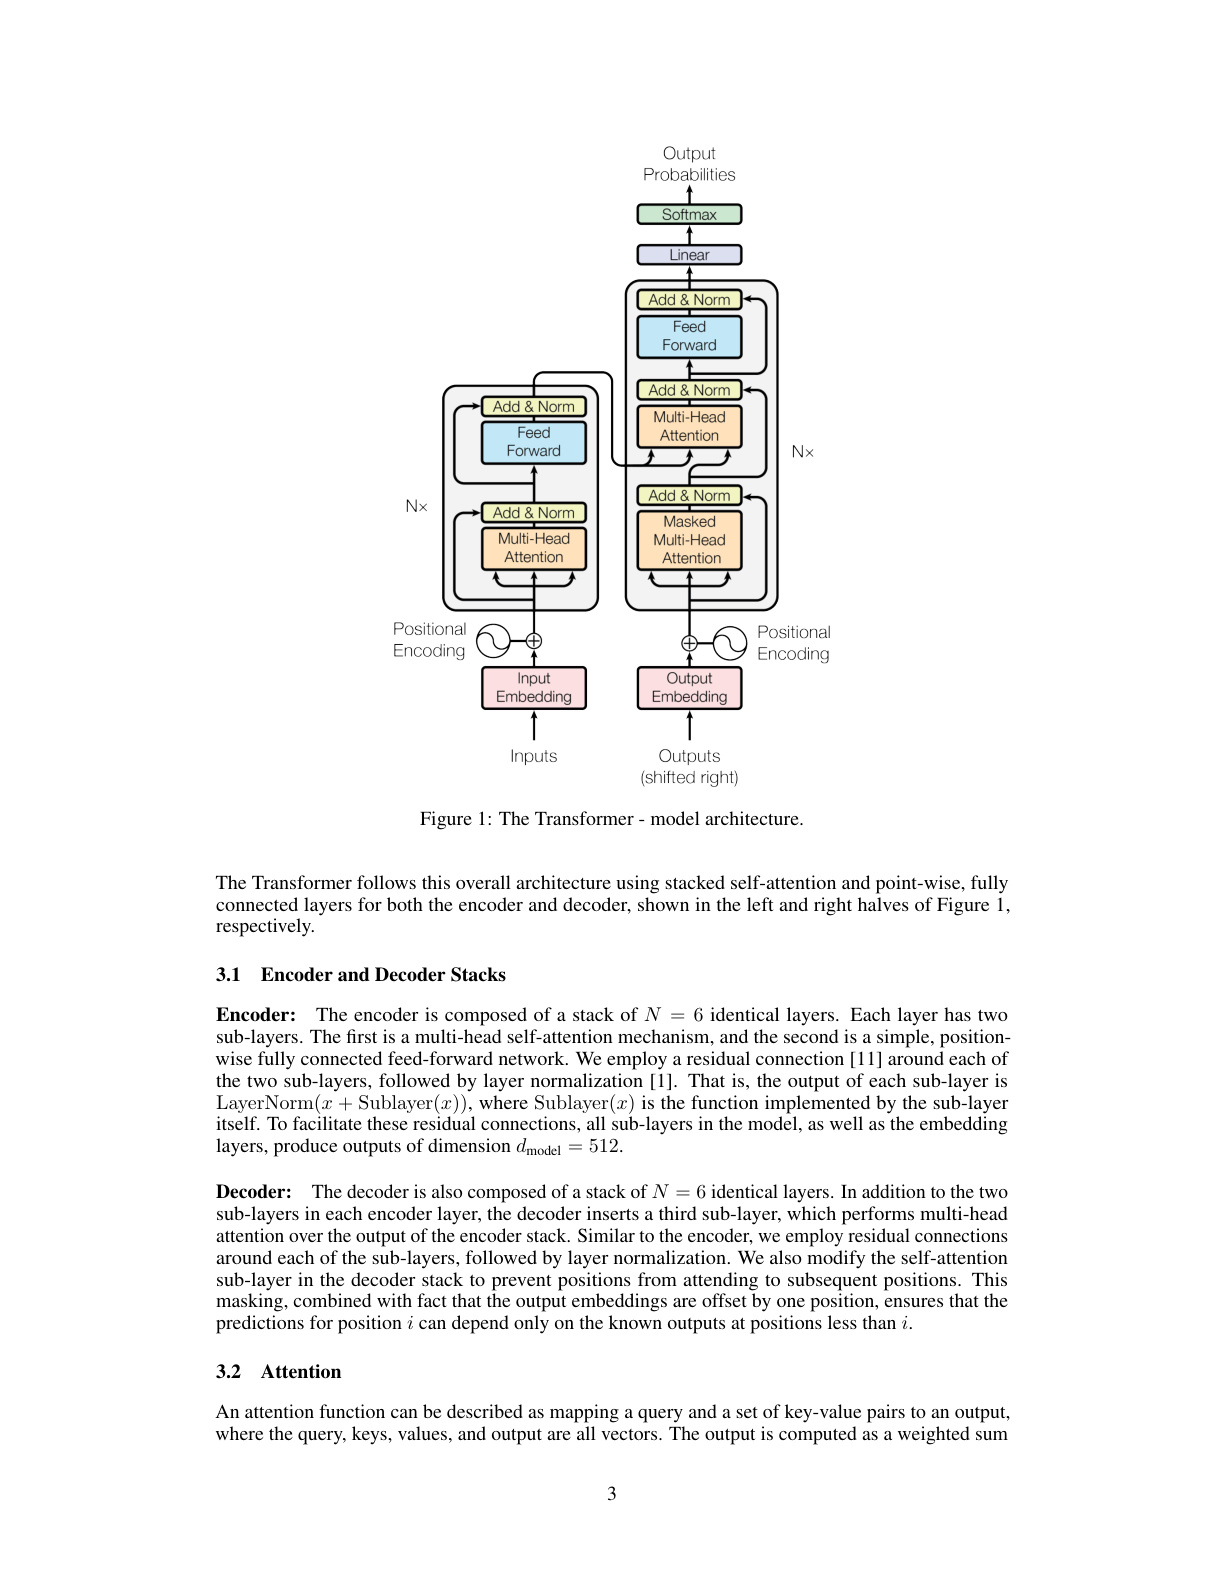

pdf_images/page_4.jpg


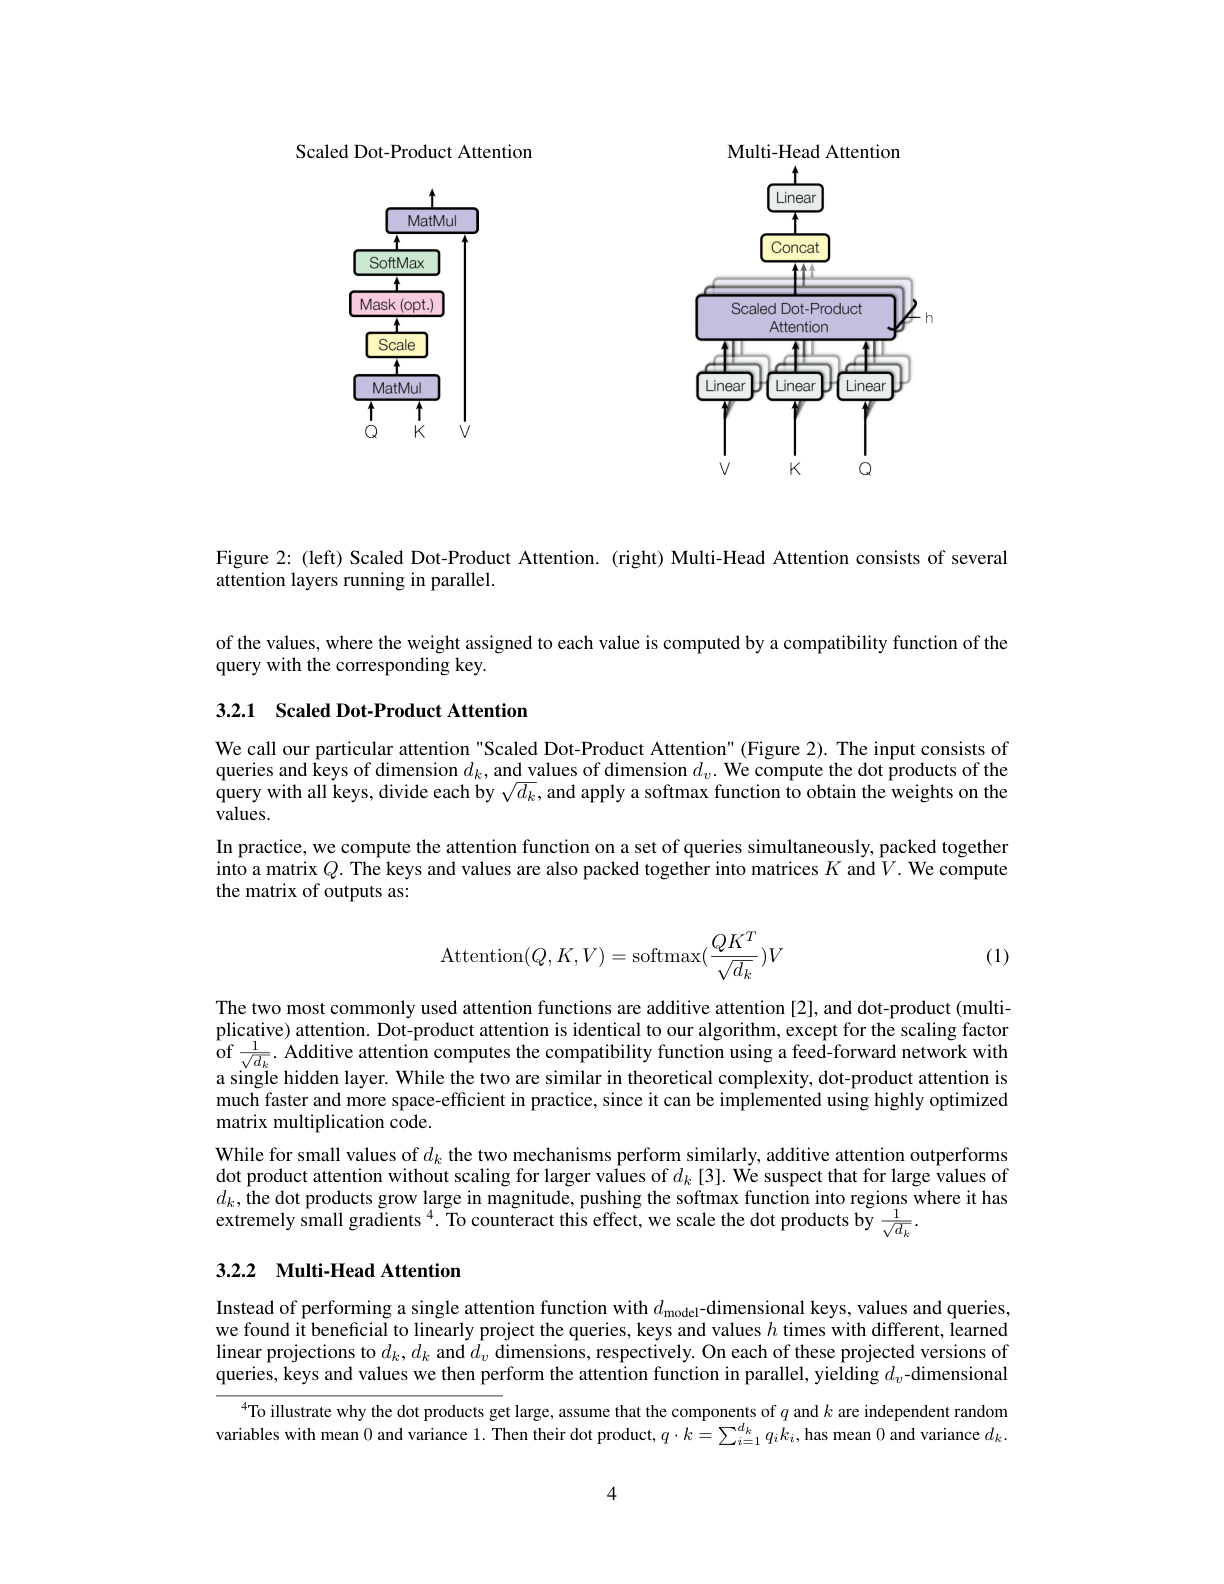

In [33]:
from IPython.display import Image, display

for image_path in retrieved_page_images:
    print(image_path)
    display(Image(filename=image_path))

In [31]:
# Generate answer using VLM with only PDF page images as visual context
answer_prompt = f"""
Answer the question based on the images of the document pages as context.

Question: {query}

Provide a answer based only on the context provided.
"""

print('Generated answer using VLM with retrieved PDF page images as visual context:\n')
answer = await call_vlm(answer_prompt, retrieved_page_images)
utils.print_wrapped(answer)

Generated answer using VLM with retrieved PDF page images as visual context:

Softmax


In [32]:
# Generate answer using VLM with only PDF page images as visual context
answer_prompt = f"""
Hello
"""

print('Generated answer using VLM with retrieved PDF page images as visual context:\n')
answer = await call_vlm(answer_prompt, retrieved_page_images)
utils.print_wrapped(answer)

Generated answer using VLM with retrieved PDF page images as visual context:

Hello! How can I assist you today?


## Conclusion

In this notebook, we demonstrated a *minimal* **vision-based, vectorless RAG pipeline** using PageIndex and a VLM. The system retrieves relevant pages by reasoning over the document’s hierarchical tree index and answers questions directly from PDF images — no OCR required.

If you’re interested in building your own **reasoning-based document QA system**, try [PageIndex Chat](https://chat.pageindex.ai), or integrate via [PageIndex MCP](https://pageindex.ai/mcp) and the [API](https://docs.pageindex.ai/quickstart). You can also explore the [GitHub repo](https://github.com/VectifyAI/PageIndex) for open-source implementations and additional examples.



© 2025 [Vectify AI](https://vectify.ai)